In [25]:
import copy
import os
import random
from dataclasses import dataclass, asdict
from itertools import product

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from torch.utils.data import DataLoader, TensorDataset, Subset
from skimage.metrics import structural_similarity as ssim

from aijack.collaborative.fedavg import FedAVGAPI, FedAVGClient, FedAVGServer
from aijack.attack.inversion import GradientInversionAttackServerManager
from aijack.defense.dp import DPSGDManager, GeneralMomentAccountant
from aijack.defense.dp.manager import DPSGDClientManager

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
RESULTS_DIR = "results_refactored"
os.makedirs(RESULTS_DIR, exist_ok=True)

REPRODUCIBILITY

In [26]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

CONFIG OBJECT 

In [27]:
@dataclass
class ExperimentConfig:
    dataset_name: str = "MNIST"
    model_name: str = "LeNet"
    activation: str = "sigmoid"

    num_clients: int = 1
    clients_per_round: int = 1
    num_rounds: int = 1
    local_epochs: int = 1
    batch_size: int = 1
    client_lr: float = 0.1

    use_dp: bool = False
    dp_sigma: float = 0.0
    dp_clip: float = 1.0

    attack_iterations: int = 100
    attack_lr: float = 1.0
    attack_distance: str = "l2"

    secret_index: int = 7
    seed: int = 0
    noniid_alpha: float | None = None

MODELS

In [28]:
class LeNet(nn.Module):
    def __init__(self, in_channels=1, num_classes=10, activation_cls=nn.Sigmoid):
        super().__init__()
        self.body = nn.Sequential(
            nn.Conv2d(in_channels, 12, kernel_size=5, padding=2, stride=2),
            activation_cls(),
            nn.Conv2d(12, 12, kernel_size=5, padding=2, stride=2),
            activation_cls(),
        )
        self.fc = nn.Linear(12 * 7 * 7, num_classes)

    def forward(self, x):
        x = self.body(x)
        x = x.view(x.size(0), -1)
        return self.fc(x)


def get_model(cfg: ExperimentConfig):
    activation_cls = nn.Sigmoid if cfg.activation.lower() == "sigmoid" else nn.ReLU

    if cfg.dataset_name == "MNIST":
        return LeNet(in_channels=1, num_classes=10, activation_cls=activation_cls).to(DEVICE)

    raise ValueError(f"Unsupported dataset: {cfg.dataset_name}")

DATASET LOADING

In [29]:
def get_mnist():
    transform = transforms.Compose([transforms.ToTensor()])
    train_dataset = torchvision.datasets.MNIST(
        root="./data", train=True, download=True, transform=transform
    )
    test_dataset = torchvision.datasets.MNIST(
        root="./data", train=False, download=True, transform=transform
    )
    return train_dataset, test_dataset

CLIENT PARTITION

In [30]:
def iid_partition(dataset, num_clients, seed=0):
    rng = np.random.default_rng(seed)
    indices = np.arange(len(dataset))
    rng.shuffle(indices)
    splits = np.array_split(indices, num_clients)
    return [Subset(dataset, split.tolist()) for split in splits]

In [31]:
def build_batch_with_secret(dataset, secret_index, batch_size, seed):
    rng = np.random.default_rng(seed + 1000 * secret_index + 10000 * batch_size)

    if batch_size == 1:
        batch_indices = [secret_index]
    else:
        batch_indices = [secret_index]
        while len(batch_indices) < batch_size:
            idx = int(rng.integers(0, len(dataset)))
            if idx != secret_index and idx not in batch_indices:
                batch_indices.append(idx)
        rng.shuffle(batch_indices)

    secret_pos = batch_indices.index(secret_index)
    x_list, y_list = [], []
    for idx in batch_indices:
        x_i, y_i = dataset[idx]
        x_list.append(x_i)
        y_list.append(int(y_i))

    x = torch.stack(x_list, dim=0)
    y = torch.tensor(y_list, dtype=torch.long)
    return x, y, secret_pos

In [32]:
@torch.no_grad()
def evaluate_model(model, dataloader, criterion=None):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_samples = 0

    for x, y in dataloader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)

        if criterion is not None:
            total_loss += criterion(logits, y).item() * x.size(0)

        preds = torch.argmax(logits, dim=1)
        total_correct += (preds == y).sum().item()
        total_samples += x.size(0)

    avg_loss = total_loss / total_samples if criterion is not None else None
    acc = total_correct / total_samples
    return avg_loss, acc

In [41]:
def make_client_and_optimizer(base_model, cfg: ExperimentConfig, local_dataset, train_dataset):
    if not cfg.use_dp:
        client = FedAVGClient(copy.deepcopy(base_model), user_id=0, lr=cfg.client_lr, device=DEVICE)
        optimizer = optim.SGD(client.parameters(), lr=cfg.client_lr)
        return client, optimizer

    # DP manager must use the actual local client dataset in this single-client setup.
    local_size = len(local_dataset)
    lot_size = min(cfg.batch_size, local_size)
    batch_size = min(cfg.batch_size, lot_size)

    accountant = GeneralMomentAccountant(noise_type="Gaussian", backend="python")
    dp_manager = DPSGDManager(
        accountant=accountant,
        optimizer_cls=optim.SGD,
        l2_norm_clip=cfg.dp_clip,
        dataset=local_dataset,
        lot_size=lot_size,
        batch_size=batch_size,
        iterations=max(cfg.local_epochs, 1),
    )
    DPFedAVGClient, DPOptimizer = DPSGDClientManager(dp_manager, sigma=cfg.dp_sigma).attach(FedAVGClient)

    client = DPFedAVGClient(copy.deepcopy(base_model), user_id=0, lr=cfg.client_lr, device=DEVICE)

    # Work around aijack DP optimizer expecting param.grad tensors to exist.
    for p in client.parameters():
        if p.requires_grad and p.grad is None:
            p.grad = torch.zeros_like(p)

    optimizer = DPOptimizer(client.parameters(), lr=cfg.client_lr)
    return client, optimizer

In [34]:
def reconstruction_metrics(secret_img, reconstructed_img):
    mse_score = float(np.mean((reconstructed_img - secret_img) ** 2))
    ssim_score = float(ssim(secret_img, reconstructed_img, data_range=1.0))
    return mse_score, ssim_score

In [37]:
def run_single_client_attack_trial(cfg: ExperimentConfig, train_dataset, test_loader):
    set_seed(cfg.seed)

    base_model = get_model(cfg)
    criterion = nn.CrossEntropyLoss()

    batch_x_cpu, batch_y_cpu, secret_pos = build_batch_with_secret(
        train_dataset, cfg.secret_index, cfg.batch_size, cfg.seed
    )
    local_dataset = TensorDataset(batch_x_cpu, batch_y_cpu)
    local_loader = DataLoader(local_dataset, batch_size=cfg.batch_size, shuffle=False)

    client, local_optimizer = make_client_and_optimizer(base_model, cfg, local_dataset, train_dataset)

    attack_manager = GradientInversionAttackServerManager(
        x_shape=(1, 28, 28),
        device=DEVICE,
        num_iteration=cfg.attack_iterations,
        lr=cfg.attack_lr,
        log_interval=20,
        optimizer_class=torch.optim.LBFGS,
        distancename=cfg.attack_distance,
    )
    AttackingServer = attack_manager.attach(FedAVGServer)
    server = AttackingServer([client], copy.deepcopy(base_model), device=DEVICE)

    api = FedAVGAPI(
        server=server,
        clients=[client],
        criterion=criterion,
        local_optimizers=[local_optimizer],
        local_dataloaders=[local_loader],
        num_communication=cfg.num_rounds,
        local_epoch=cfg.local_epochs,
        use_gradients=True,
        device=DEVICE,
    )

    api.run()

    # true utility: evaluate the resulting trained model on held-out test set
    test_loss, test_acc = evaluate_model(client, test_loader, criterion)

    # attack result
    recon_x, recon_y = server.attack_results[-1][0]
    secret_img = batch_x_cpu[secret_pos].detach().cpu().numpy().squeeze()

    recon_cpu = recon_x.detach().cpu()
    if recon_cpu.ndim == 4:
        candidates = [recon_cpu[i].numpy().squeeze() for i in range(recon_cpu.shape[0])]
    else:
        candidates = [recon_cpu.numpy().squeeze()]

    mses = [np.mean((cand - secret_img) ** 2) for cand in candidates]
    best_idx = int(np.argmin(mses))
    best_recon = candidates[best_idx]

    mse_score, ssim_score = reconstruction_metrics(secret_img, best_recon)

    return {
        **asdict(cfg),
        "secret_pos": int(secret_pos),
        "test_loss": float(test_loss) if test_loss is not None else None,
        "test_acc": float(test_acc),
        "attack_mse": float(mse_score),
        "attack_ssim": float(ssim_score),
    }

In [42]:
train_dataset, test_dataset = get_mnist()
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

results = []
for batch_size, sigma, seed in product([1, 4, 8, 16], [0.0, 0.01, 0.05, 0.1], [0, 1, 2]):
    cfg = ExperimentConfig(
        dataset_name="MNIST",
        activation="sigmoid",
        batch_size=batch_size,
        num_rounds=1,
        local_epochs=1,
        use_dp=(sigma > 0),
        dp_sigma=sigma,
        dp_clip=1.0,
        seed=seed,
        secret_index=7,
    )
    out = run_single_client_attack_trial(cfg, train_dataset, test_loader)
    results.append(out)

df = pd.DataFrame(results)
df.to_csv(os.path.join(RESULTS_DIR, "mnist_dp_batchsize_tradeoff.csv"), index=False)
df.head()

iter=20: 5.441537442862909e-09, (best_iter=9: 5.441537442862909e-09)
iter=40: 5.441537442862909e-09, (best_iter=9: 5.441537442862909e-09)
iter=60: 5.441537442862909e-09, (best_iter=9: 5.441537442862909e-09)
iter=60: loss did not improve in the last 50 rounds.
iter=20: 5.500668809332865e-09, (best_iter=6: 5.500668809332865e-09)
iter=40: 5.500668809332865e-09, (best_iter=6: 5.500668809332865e-09)
iter=57: loss did not improve in the last 50 rounds.
iter=20: 6.907621585838797e-09, (best_iter=7: 6.907621585838797e-09)
iter=40: 6.907621585838797e-09, (best_iter=7: 6.907621585838797e-09)
iter=58: loss did not improve in the last 50 rounds.
communication 0, epoch 0: client-1 2.212738513946533
iter=20: 116.21176147460938, (best_iter=2: 6.575657844543457)
iter=40: 116.21176147460938, (best_iter=2: 6.575657844543457)
iter=53: loss did not improve in the last 50 rounds.
communication 0, epoch 0: client-1 2.1215672492980957
iter=20: 153.69459533691406, (best_iter=2: 6.643543243408203)
iter=40: 153

,dataset_name,model_name,activation,num_clients,clients_per_round,num_rounds,local_epochs,batch_size,client_lr,use_dp,...,attack_lr,attack_distance,secret_index,seed,noniid_alpha,secret_pos,test_loss,test_acc,attack_mse,attack_ssim
0,MNIST,LeNet,sigmoid,1,1,1,1,1,0.1,False,...,1.0,l2,7,0,None,0,13.228685,0.101,1.555841e-06,0.999885
1,MNIST,LeNet,sigmoid,1,1,1,1,1,0.1,False,...,1.0,l2,7,1,None,0,11.909290,0.101,5.756340e-07,0.999911
2,MNIST,LeNet,sigmoid,1,1,1,1,1,0.1,False,...,1.0,l2,7,2,None,0,12.215744,0.101,1.995473e-06,0.999847
3,MNIST,LeNet,sigmoid,1,1,1,1,1,0.1,True,...,1.0,l2,7,0,None,0,2.443177,0.101,5.244315e+03,-0.000014
4,MNIST,LeNet,sigmoid,1,1,1,1,1,0.1,True,...,1.0,l2,7,1,None,0,2.467926,0.101,5.975145e+02,-0.000091


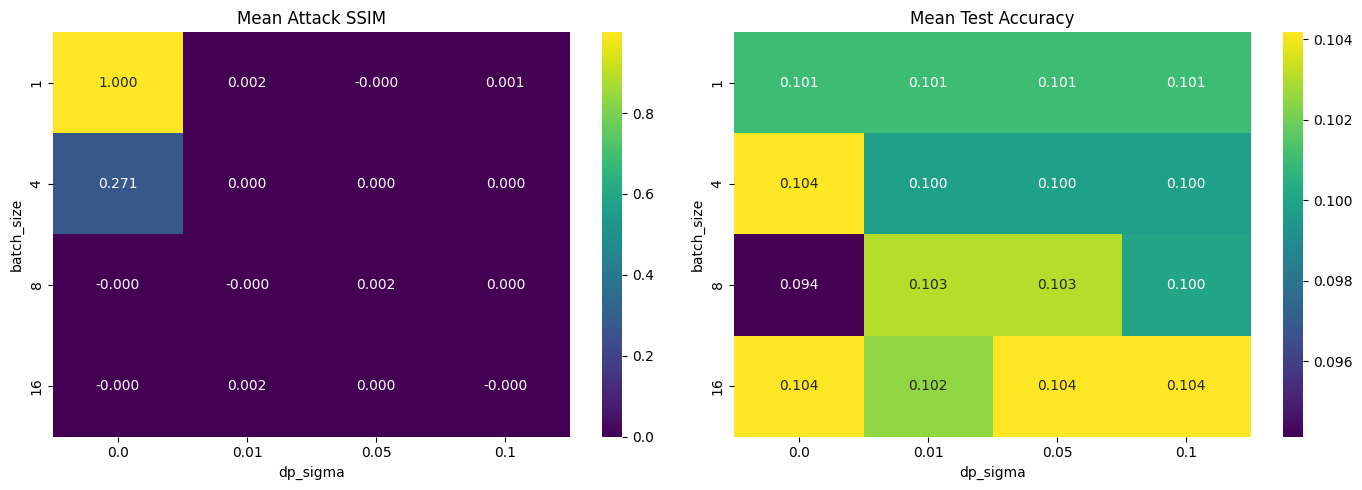

In [43]:
import seaborn as sns
import matplotlib.pyplot as plt

summary_df = df.groupby(["batch_size", "dp_sigma"]).agg({
    "attack_ssim": ["mean", "std"],
    "test_acc": ["mean", "std"]
}).reset_index()
summary_df.columns = ["_".join(col).strip() if col[1] else col[0] for col in summary_df.columns.values]
summary_df = summary_df.rename(columns={"batch_size_": "batch_size", "dp_sigma_": "dp_sigma"})

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ssim_pivot = summary_df.pivot(index="batch_size", columns="dp_sigma", values="attack_ssim_mean")
sns.heatmap(ssim_pivot, annot=True, fmt=".3f", cmap="viridis", ax=axes[0])
axes[0].set_title("Mean Attack SSIM")

acc_pivot = summary_df.pivot(index="batch_size", columns="dp_sigma", values="test_acc_mean")
sns.heatmap(acc_pivot, annot=True, fmt=".3f", cmap="viridis", ax=axes[1])
axes[1].set_title("Mean Test Accuracy")

plt.tight_layout()
plt.show()